<a href="https://colab.research.google.com/github/martinamoralesb-lab/ICS40125-entregables/blob/main/docs/projects/project_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/projects/project_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Analítica de Recursos Humanos: Determinantes Salariales y Modelación de Compensaciones


## Contexto y Objetivo

Una firma multinacional de consultoría ha sido contratada por **TalentCo**, empresa con operaciones en múltiples regiones y departamentos, para analizar su estructura de compensaciones. El equipo de Recursos Humanos sospecha que los salarios no están siendo asignados de manera consistente: algunos empleados se sienten subpagados en relación con pares de experiencia similar, mientras que otros en el mismo departamento perciben montos significativamente distintos según su región o nivel educacional.

Su rol es actuar como **Analista de Datos** en la firma consultora. Utilizará Python, pruebas de hipótesis estadísticas y regresión lineal para identificar los principales determinantes del salario de los empleados, y entregará recomendaciones basadas en datos a la dirección de TalentCo.

Al finalizar este proyecto, usted será capaz de:

- Realizar análisis exploratorio de datos (EDA) sobre datos de Recursos Humanos.
- Aplicar pruebas de hipótesis para validar supuestos de negocio.
- Manejar variables categóricas mediante técnicas de codificación.
- Construir y evaluar modelos de regresión con OLS y scikit-learn.
- Verificar los supuestos de regresión (multicolinealidad, normalidad, homocedasticidad).
- Comunicar resultados en un informe orientado al negocio.



## Conjunto de Datos: `employee_compensation.csv`

Disponible en la sección de materiales del curso. Contiene registros de **1.500 empleados** distribuidos en distintos departamentos, regiones y niveles de cargo.

| Variable | Tipo | Descripción |
|---|---|---|
| `Salary` | Numérica (USD/año) | Salario bruto anual — **variable objetivo** |
| `Years_Experience` | Numérica | Total de años de experiencia profesional |
| `Age` | Numérica | Edad del empleado |
| `Performance_Score` | Numérica (1.0–5.0) | Calificación de desempeño anual más reciente |
| `Education_Level` | Categórica | Bachelor, Master, PhD |
| `Department` | Categórica | Engineering, Sales, Marketing, HR, Finance |
| `Region` | Categórica | North, South, East, West |
| `Job_Level` | Categórica | Junior, Mid, Senior |
| `Gender` | Categórica | Male, Female |




> **Nota sobre la generación del dataset:** Este conjunto de datos puede generarse sintéticamente con `numpy` y `pandas`, utilizando distribuciones salariales realistas por departamento y nivel de cargo. Se incluirá un script de generación (`generate_dataset.py`) junto al dataset.

In [4]:
import pandas as pd

# cargar datos
path = 'https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/projects/data/employee_compensation.csv'
df = pd.read_csv(path, sep="," )

df.head()

,Salary,Years_Experience,Age,Performance_Score,Education_Level,Department,Region,Job_Level,Gender
0,69181.0,3.0,22.0,3.5,Bachelor,Sales,East,Junior,Male
1,88466.0,5.0,23.0,2.8,bachelor,FINANCE,West,Junior,Female
2,76112.0,11.0,29.0,1.6,Master,HR,West,Mid,Female
3,NaN,15.0,37.0,NaN,Bachelor,Marketing,South,Senior,Male
4,NaN,6.0,28.0,4.5,Bachelor,Engineering,North,Mid,Female


## Parte 1: Análisis Exploratorio de Datos (EDA)

1. Cargue el dataset en un DataFrame de pandas.
2. Muestre las primeras 10 filas e inspeccione los tipos de datos.
3. Verifique valores faltantes y duplicados; reporte los hallazgos.
4. Calcule estadísticas descriptivas (media, mediana, desviación estándar, mínimo, máximo) para todas las variables numéricas.
5. Elabore al menos **tres** de las siguientes visualizaciones:
   - Histograma del salario.
   - Diagrama de caja (*box plot*) del salario por nivel de cargo.
   - Diagrama de dispersión de años de experiencia vs. salario.
   - Gráfico de barras del salario promedio por departamento.
   - Mapa de calor de correlaciones entre variables numéricas.



1. Cargue el dataset en un DataFrame de pandas.

In [5]:
#fixme
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# cargar dataset
path = 'https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/projects/data/employee_compensation.csv'

df = pd.read_csv(path)

# mostrar primeras filas
df.head()

,Salary,Years_Experience,Age,Performance_Score,Education_Level,Department,Region,Job_Level,Gender
0,69181.0,3.0,22.0,3.5,Bachelor,Sales,East,Junior,Male
1,88466.0,5.0,23.0,2.8,bachelor,FINANCE,West,Junior,Female
2,76112.0,11.0,29.0,1.6,Master,HR,West,Mid,Female
3,NaN,15.0,37.0,NaN,Bachelor,Marketing,South,Senior,Male
4,NaN,6.0,28.0,4.5,Bachelor,Engineering,North,Mid,Female


2. Muestre las primeras 10 filas e inspeccione los tipos de datos.

In [6]:
# mostrar primeras 10 filas
print(df.head(10))

# tipos de datos
print(df.dtypes)

    Salary  Years_Experience   Age  Performance_Score Education_Level  \
0  69181.0               3.0  22.0                3.5        Bachelor   
1  88466.0               5.0  23.0                2.8        bachelor   
2  76112.0              11.0  29.0                1.6          Master   
3      NaN              15.0  37.0                NaN        Bachelor   
4      NaN               6.0  28.0                4.5        Bachelor   
5  81246.0               4.0  21.0                2.8        Bachelor   
6  71494.0               4.0  23.0                2.4        Bachelor   
7  78189.0               3.0  21.0                3.5          Master   
8  67204.0               0.0  21.0                3.5          Master   
9  59776.0               4.0  24.0                NaN        Bachelor   

    Department Region Job_Level  Gender  
0        Sales   East    Junior    Male  
1      FINANCE   West    Junior  Female  
2           HR   West       Mid  Female  
3    Marketing  South    Sen

3. Verifique valores faltantes y duplicados; reporte los hallazgos.

In [7]:
# valores faltantes
print("Valores faltantes por columna:")
print(df.isnull().sum())

# duplicados
print("\nCantidad de filas duplicadas:")
print(df.duplicated().sum())

Valores faltantes por columna:
Salary               203
Years_Experience     405
Age                  303
Performance_Score    603
Education_Level      506
Department           305
Region               401
Job_Level              0
Gender               501
dtype: int64

Cantidad de filas duplicadas:
97


Se identificaron valores faltantes en variables como Salary y Performance_Score.
Además, se verificó la existencia de registros duplicados en el dataset para evaluar la calidad de los datos.

4. Calcule estadísticas descriptivas (media, mediana, desviación estándar, mínimo, máximo) para todas las variables numéricas.

In [8]:
# estadísticas descriptivas
df.describe()


,Salary,Years_Experience,Age,Performance_Score
count,9897.000000,9695.000000,9797.000000,9497.000000
mean,95728.604527,6.817019,29.460855,3.028188
std,30599.451256,5.688109,6.845404,1.809318
min,5342.000000,-10.000000,1.000000,-1.000000
25%,76834.000000,2.000000,25.000000,2.000000
50%,91701.000000,6.000000,29.000000,3.000000
75%,111908.000000,10.000000,34.000000,4.000000
max,394249.000000,78.000000,119.000000,99.000000


5. Elabore al menos tres de las siguientes visualizaciones:


# **Histograma del salario**

In [9]:
#limpieza de datos
# estandarizar texto
df['Education_Level'] = df['Education_Level'].str.capitalize()
df['Department'] = df['Department'].str.capitalize()
df['Job_Level'] = df['Job_Level'].str.capitalize()
df['Region'] = df['Region'].str.capitalize()
df['Gender'] = df['Gender'].str.capitalize()

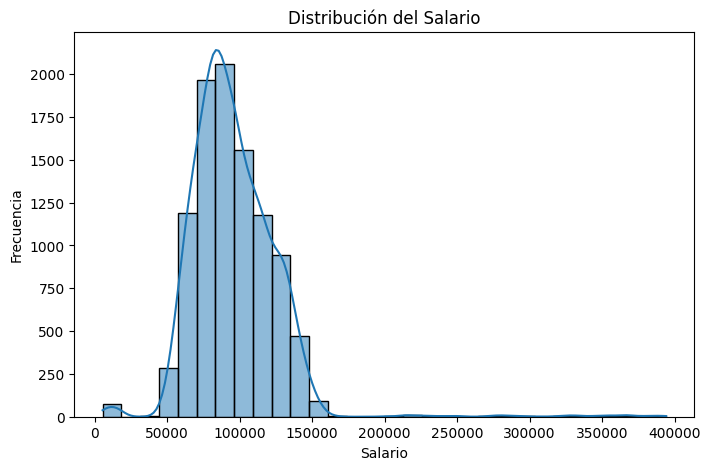

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

#histograma de salkario
plt.figure(figsize=(8,5))

sns.histplot(df['Salary'], bins=30, kde=True)

plt.title('Distribución del Salario')
plt.xlabel('Salario')
plt.ylabel('Frecuencia')

plt.show()

La distribución salarial presenta una tendencia aproximadamente normal, aunque con presencia de salarios altos que generan asimetría positiva.

(la mayoria de los empleados tienen salarios cercanos al promedio
hay pocos empleados con salarios extremadamente bajos o altos)

# **Diagrama de caja (box plot) del salario por nivel de cargo**

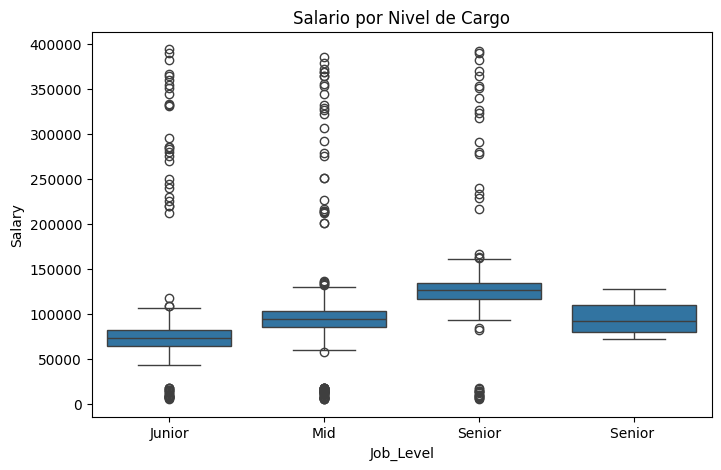

In [11]:
#Boxplot salario por nivel de cargo
plt.figure(figsize=(8,5))

sns.boxplot(x='Job_Level', y='Salary', data=df)

plt.title('Salario por Nivel de Cargo')

plt.show()

Los empleados Senior presentan salarios más altos y mayor dispersión respecto a los niveles Junior y Mid.

(los salarios de los senior son mas altos y mas variados entre ellos, no necesariamente estan alejados de la media)

# **Diagrama de dispersión de años de experiencia vs. salario**

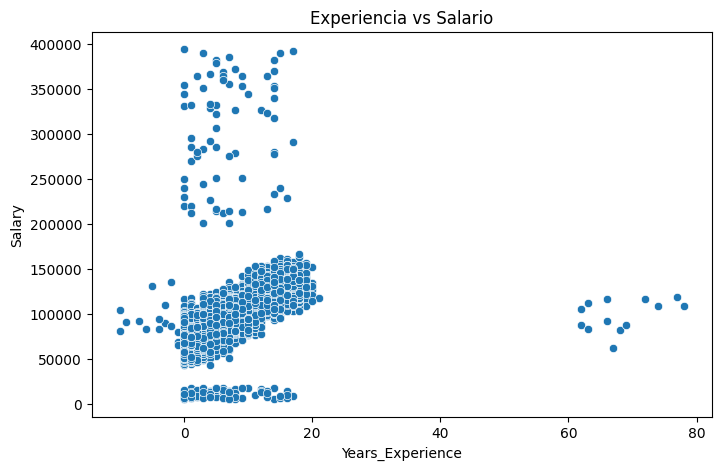

In [12]:
#Diagrama de dispersión de años de experiencia vs. salario.
plt.figure(figsize=(8,5))

sns.scatterplot(x='Years_Experience', y='Salary', data=df)

plt.title('Experiencia vs Salario')

plt.show()

Se observa una relación positiva entre los años de experiencia y el salario, sugiriendo que empleados con mayor experiencia tienden a percibir mayores compensaciones.

# **Gráfico de barras del salario promedio por departamento**

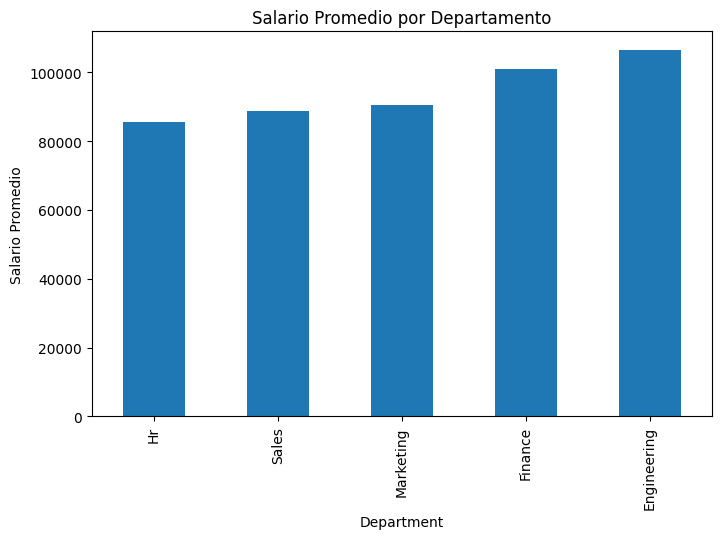

In [13]:
#Gráfico de barras del salario promedio por departamento.
plt.figure(figsize=(8,5))

df.groupby('Department')['Salary'].mean().sort_values().plot(kind='bar')

plt.title('Salario Promedio por Departamento')
plt.ylabel('Salario Promedio')

plt.show()

Existen diferencias salariales entre departamentos, siendo Engineering y Finance los que presentan mayores salarios promedio.

# **Mapa de calor de correlaciones entre variables numéricas**

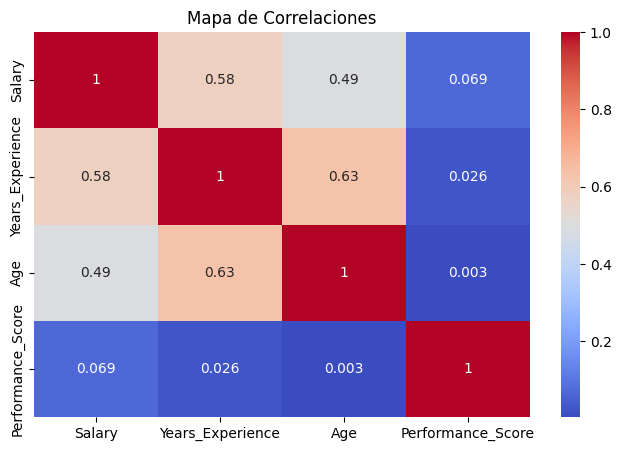

In [14]:
#Mapa de calor de correlaciones entre variables numéricas.
plt.figure(figsize=(8,5))

corr = df[['Salary', 'Years_Experience', 'Age', 'Performance_Score']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Mapa de Correlaciones')

plt.show()

La variable Years_Experience presenta una correlación positiva moderada/alta con Salary, indicando una posible relación lineal relevante.
“A medida que aumentan los años de experiencia, el salario también tiende a aumentar.”



## Parte 2: Pruebas de Hipótesis

**Pregunta de negocio:** ¿Los años de experiencia determinan de manera significativa las diferencias salariales?

1. Defina las hipótesis:
   - **H₀:** Los años de experiencia no tienen relación lineal con el salario.
   - **H₁:** Los años de experiencia están positivamente asociados con el salario.

2. Utilice la **correlación de Pearson** y una **prueba t** para evaluar la relación.

3. Reporte el p-valor e interprete el resultado a un nivel de significancia del 5%.

4. **(Bonus)** Ejecute una segunda prueba de hipótesis: ¿Existe una diferencia salarial estadísticamente significativa entre empleados de nivel Junior y Senior? Utilice una prueba t de dos muestras independientes.



In [ ]:
#fixme

2. Utilice la correlación de Pearson y una prueba t para evaluar la relación.

In [15]:
from scipy.stats import pearsonr

# eliminar nulos
data = df[['Years_Experience', 'Salary']].dropna()

# correlación
corr, p_value = pearsonr(data['Years_Experience'], data['Salary'])

print("Correlación:", corr)
print("P-valor:", p_value)

Correlación: 0.5764837547948911
P-valor: 0.0


3. Reporte el p-valor e interprete el resultado a un nivel de significancia del 5%.

In [16]:
if p_value < 0.05:
    print("Se rechaza H0: existe relación significativa entre experiencia y salario.")
else:
    print("No se rechaza H0.")

Se rechaza H0: existe relación significativa entre experiencia y salario.


La prueba de correlación de Pearson mostró una relación positiva y estadísticamente significativa entre Years_Experience y Salary (p < 0.05).
Por lo tanto, se rechaza la hipótesis nula y se concluye que la experiencia influye significativamente en el salario.

4. (Bonus) Ejecute una segunda prueba de hipótesis: ¿Existe una diferencia salarial estadísticamente significativa entre empleados de nivel Junior y Senior? Utilice una prueba t de dos muestras independientes.

In [17]:
from scipy.stats import ttest_ind

# salarios junior
junior = df[df['Job_Level'] == 'Junior']['Salary'].dropna()

# salarios senior
senior = df[df['Job_Level'] == 'Senior']['Salary'].dropna()

# prueba t
t_stat, p_value = ttest_ind(junior, senior)

print("T-statistic:", t_stat)
print("P-valor:", p_value)

T-statistic: -83.23647935055853
P-valor: 0.0


In [18]:
if p_value < 0.05:
    print("Existe diferencia salarial significativa entre Junior y Senior.")
else:
    print("No existe diferencia significativa.")

Existe diferencia salarial significativa entre Junior y Senior.


La prueba t de muestras independientes evidenció diferencias salariales estadísticamente significativas entre empleados Junior y Senior (p < 0.05), indicando que el nivel de cargo impacta de manera importante en la compensación.



## Parte 3: Regresión Lineal con Variables Categóricas

### Paso 1: Justificación de variables (antes de codificar)

Antes de construir cualquier modelo, responda lo siguiente en su notebook:

- ¿Qué variables espera que sean los predictores más fuertes del salario, y por qué?
- ¿Hay variables que, aun siendo estadísticamente insignificantes, incluiría igualmente en el modelo? Justifique desde una perspectiva de negocio o teórica.
- ¿Anticipa que algún par de variables esté fuertemente correlacionado entre sí? ¿Cuáles, y por qué? ¿Qué problemas podría causar eso?

> Este paso debe responderse en texto libre, sin código. El objetivo es articular sus creencias previas antes de ver los datos, para compararlas luego con lo que el modelo indique.

### Paso 2: Preparación de los datos

- Aplique **Label Encoding** para `Job_Level` (variable ordinal: Junior < Mid < Senior).
- Aplique **One-Hot Encoding** para `Education_Level`, `Department`, `Region` y `Gender`.
- Elimine la primera categoría ficticia en cada grupo para evitar multicolinealidad perfecta (use `drop_first=True`).

### Paso 3: Construcción del modelo

1. Divida el dataset en conjuntos de entrenamiento (80%) y prueba (20%). Use `random_state=42`.
2. Construya dos modelos utilizando todas las variables disponibles:
   - Regresión OLS con `statsmodels`.
   - Regresión lineal con `scikit-learn`.

### Paso 4: Evaluación del modelo

Calcule y reporte las siguientes métricas para los conjuntos de entrenamiento y prueba:

| Métrica | Descripción |
|---|---|
| MAE | Error Absoluto Medio |
| MAPE | Error Porcentual Absoluto Medio |
| RMSE | Raíz del Error Cuadrático Medio |
| R² | Coeficiente de determinación |
| R² ajustado | R² penalizado por el número de predictores |

Compare el resumen OLS (coeficientes, p-valores, R²) con los resultados de scikit-learn.



In [ ]:
#fixme



## Parte 4: Análisis y Refinamiento del Modelo

> **Nota importante:** El objetivo de esta sección no es aplicar reglas mecánicas. No existe un umbral universal que indique cuándo incluir o excluir una variable. Toda decisión debe argumentarse desde el contexto del problema.

### Paso 1: Interpretación de los p-valores de los coeficientes

Examine los p-valores del resumen OLS y responda lo siguiente para cada variable con p-valor > 0,05:

- ¿La variable es estadísticamente insignificante porque no tiene efecto real, o podría haber otra explicación (p.ej., correlación con otra variable ya incluida en el modelo)?
- ¿Es esta variable conceptualmente importante para el análisis salarial, aunque el modelo no encuentre un efecto significativo? ¿Su eliminación cambiaría la interpretación de otros coeficientes?
- ¿Cuál es el costo para el negocio de eliminar esta variable del modelo?

Con base en este análisis, decida qué variables conservar o eliminar, y justifique explícitamente cada decisión. Vuelva a entrenar el modelo con las variables seleccionadas y compare las métricas con el modelo completo.

**Ejemplo del razonamiento esperado:** *"Gender presenta p = 0,18 en nuestro modelo. Sin embargo, optamos por conservarla porque: (1) la equidad salarial por género es una de las preguntas centrales de TalentCo, y (2) su insignificancia puede deberse a colinealidad con Job_Level más que a la ausencia de efecto. Eliminarla ocultaría una dimensión clave del análisis."*

### Paso 2: Análisis de Multicolinealidad (VIF)

Calcule el **Factor de Inflación de la Varianza (VIF)** para todas las variables independientes y responda:

- ¿Qué pares de variables probablemente generan VIF alto, y por qué existe esa correlación en este contexto?
- ¿La presencia de multicolinealidad invalida las predicciones del modelo, o afecta principalmente la confiabilidad de los coeficientes individuales?
- Para cada variable con VIF alto: ¿qué se perdería al eliminarla? ¿Es aceptable esa pérdida dado el objetivo del análisis?

Decida si actuar sobre la multicolinealidad y justifique su decisión. Mantener variables colineales es una respuesta válida si el razonamiento lo sustenta.

**Ejemplo del razonamiento esperado:** *"Age y Years_Experience presentan VIF = 8,4 y 9,1 respectivamente, lo que refleja que los empleados de mayor edad tienden a tener más experiencia. Ambas variables capturan dimensiones distintas —edad biológica vs. tiempo profesional acumulado—, por lo que las conservamos y reconocemos los errores estándar inflados como una limitación del modelo."*

### Paso 3: Verificación de Supuestos de Regresión

Verifique los siguientes supuestos de la regresión lineal sobre su modelo final:

- **Normalidad de los residuos:** Histograma y gráfico Q-Q de los residuos.
- **Homocedasticidad:** Aplique la prueba de Breusch-Pagan (`het_breuschpagan`).

Para cada supuesto, indique si se cumple, muestre la evidencia y discuta brevemente qué implica para la validez de sus conclusiones.



In [ ]:
#fixme



## Parte 5: Informe de Negocio

Redacte un informe ejecutivo breve (**300–400 palabras**) dirigido al **Director de Recursos Humanos de TalentCo**, respondiendo las siguientes preguntas:

1. ¿Cuáles son los principales determinantes del salario de los empleados?
2. ¿Cómo impacta cuantitativamente el nivel de experiencia en la compensación anual?
3. ¿Existen diferencias salariales significativas entre departamentos o regiones? ¿Qué sugieren?
4. Según su modelo final: si TalentCo asciende a un empleado de nivel Mid a Senior, ¿cuál es el aumento salarial esperado (en USD)?
5. ¿Qué recomendaciones haría a TalentCo para mejorar la equidad y transparencia en su política de compensaciones?



In [ ]:
#fixme


## Entregables

Cada estudiante o grupo debe entregar los siguientes elementos:

| # | Entregable | Descripción |
|---|---|---|
| 1 | **Jupyter Notebook** (`.ipynb`) | Código completo con salidas y comentarios en línea. Debe ser limpio, bien comentado y reproducible. Todos los gráficos deben incluir títulos, etiquetas de ejes y leyendas cuando corresponda. |
| 2 | **Informe de Negocio** (`.md` o `.docx`) | 300 a 400 palabras, dirigido a una audiencia no técnica. |
| 3 | **Presentación Oral** | 10 a 12 minutos (ver rúbrica). |

> ⚠️ **Importante:** Tanto la entrega escrita como la presentación oral son **obligatorias**. La ausencia de cualquiera de los dos componentes resulta en la nota mínima del proyecto.



## Consejos Técnicos

- Utilice las bibliotecas: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn` y `statsmodels`.
- Para VIF: `from statsmodels.stats.outliers_influence import variance_inflation_factor`
- Para Breusch-Pagan: `from statsmodels.stats.diagnostic import het_breuschpagan`
- Para gráfico Q-Q: `import scipy.stats as stats; stats.probplot(residuals, plot=plt)`
- Priorice la **interpretación de negocio** por sobre los resultados estadísticos aislados.
- En el informe ejecutivo, escriba para el Director de RRHH: sin fórmulas, sin código, sin p-valores. Solo conclusiones claras y accionables.



## Rúbrica de Presentación Oral

Cada grupo será evaluado en una escala de 10 a 100 puntos. Las presentaciones deben realizarse en español o inglés y tener una duración de entre 10 y 12 minutos.

### Criterios de Evaluación

| Criterio | Descripción | Puntaje | Ponderación |
|---|---|---|---|
| **1. Comprensión del problema y contexto** | Demuestra comprensión clara del problema de negocio de TalentCo y del valor del análisis basado en datos. Vincula los hallazgos estadísticos con decisiones reales de RRHH. | 10–20 pts | 20% |
| **2. Exploración de datos e insights** | Presenta los hallazgos del EDA de forma clara. Destaca patrones relevantes (p.ej., salario por departamento, tendencias de experiencia). Explica cómo el análisis orientó las decisiones de modelado. | 10–20 pts | 20% |
| **3. Explicación del modelo y resultados** | Explica los modelos de regresión, las decisiones de codificación y las métricas de evaluación (MAE, RMSE, R²) con precisión. Compara OLS vs. sklearn y justifica el modelo final. | 10–20 pts | 20% |
| **4. Interpretación de negocio y recomendaciones** | Traduce los coeficientes del modelo y los resultados de las pruebas en recomendaciones accionables para RRHH. Explica qué debe hacer TalentCo y por qué, sin jerga técnica. | 10–20 pts | 20% |
| **5. Comunicación y presentación** | Exposición clara y profesional en español o inglés. Flujo lógico, tono seguro y trabajo en equipo efectivo. Respeta el tiempo establecido. | 10–15 pts | 15% |
| **6. Apoyos visuales y diseño de diapositivas** | Las diapositivas son claras, profesionales y apoyan la narrativa. Los gráficos y tablas son legibles y están bien etiquetados. Evita diapositivas con exceso de texto. | 10–15 pts | 15% |

### Escala de Calificación

| Puntaje | Nivel | Descripción |
|---|---|---|
| 90–100 | ⭐ Sobresaliente | Comprensión excepcional, insights de negocio sólidos y presentación atractiva. Vínculo claro entre el análisis de datos y la estrategia de RRHH. |
| 80–89 | ✅ Muy Bueno | Explicación y visuales sólidos, con brechas menores en profundidad o fluidez. Buen dominio técnico y de negocio. |
| 70–79 | ⚙️ Bueno | Cubre los puntos principales de manera adecuada, pero con falta de profundidad o claridad en algunas áreas. Estructura razonable. |
| 60–69 | ⚠️ Aceptable | Cobertura básica con insight de negocio limitado o conexión débil con el problema de RRHH. Presentación algo confusa o apresurada. |
| 10–59 | ❌ Insuficiente | Estructura deficiente, contenido incompleto o incapacidad para comunicar los hallazgos. Puede exceder o quedar muy por debajo del tiempo establecido. |

### Notas para Evaluadores

- Descontar hasta **−10 puntos** si la presentación no se encuentra dentro del rango de tiempo (menos de 7 min o más de 13 min).
- Descontar hasta **−5 puntos** si no todos los integrantes participan activamente.
- Otorgar hasta **+5 puntos de bonificación** por insight excepcional, creatividad o conexión con casos reales.

**Puntaje máximo:** 100 puntos | **Nota mínima de aprobación:** 60 puntos
